# FRTEngine2 — Profiling Analysis

Parses a profiling session (`Local/Profiling/<session>/`) and produces thesis
evaluation output — speedup tables, plots, cost-model checks.

Run cells top to bottom. `%autoreload` is on: edit any `frtprof/*.py` and
re-run a cell — no kernel restart needed.

In [85]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [86]:
from pathlib import Path

from frtprof import load, metrics, plots, tables, costmodel

## Configuration

Point `SESSION_DIR` at a session folder. Figures and tables are written to
`<session>/analysis/`.

In [87]:
# Edit this to analyse a different session.
SESSION_DIR = Path("P:/Edu/FRTEngine2/Local/Profiling/session")
OUT_DIR = SESSION_DIR / "analysis"

print("session:", SESSION_DIR)
print("output :", OUT_DIR)

session: P:\Edu\FRTEngine2\Local\Profiling\session
output : P:\Edu\FRTEngine2\Local\Profiling\session\analysis


## Load session

In [88]:
sess = load.load_session(SESSION_DIR)
frames = sess["frames"]
profiles = sess["profiles"]
portals = sess["portals"]

print(f"{profiles['config_index'].nunique()} profiles, {len(frames)} frames")
profiles.head()

96 profiles, 48000 frames


,config_index,spp,max_bounces,rr_depth,portal_prefilter,render_width,render_height,entity_count,triangle_count,point_lights,...,reached_sky_p50,reached_sky_p95,blocked_mean,blocked_std,blocked_p50,blocked_p95,portal_tests_mean,portal_tests_std,portal_tests_p50,portal_tests_p95
0,0,4,2,2,0,1242,673,11,301469,0,...,7760.0,7915.10,2275073.754,1347.479161,2275050.0,2277512.00,0.000,0.000000,0.0,0.00
1,1,4,2,2,1,1242,673,11,301469,0,...,3.0,5.05,9125.130,95.385186,9126.0,9282.05,4564079.874,1653.305502,4564124.0,4566929.35
2,2,4,2,3,0,1242,673,11,301469,0,...,7754.0,7899.00,2274392.330,1302.937325,2274397.0,2276515.55,0.000,0.000000,0.0,0.00
3,3,4,2,3,1,1242,673,11,301469,0,...,2.0,5.00,9106.274,100.084067,9108.0,9267.00,4563988.806,1627.221565,4564061.5,4566575.05
4,4,4,2,4,0,1242,673,11,301469,0,...,7765.0,7903.05,2274979.456,1409.277990,2274926.0,2277470.55,0.000,0.000000,0.0,0.00


## Sanity checks

Invariants that must hold for every export: portal-off rows have no
rejections, and `portal_pass + portal_rej == sky_attempted`.

In [89]:
issues = metrics.sanity_check(frames)
print("OK - no violations" if not issues else "\n".join(issues))

OK - no violations


## Portal off vs on - speedup

In [90]:
paired = metrics.pair_portals(profiles)
summary = metrics.paired_summary(paired)
summary

,spp,bounces,rr,rt_off_ms,rt_on_ms,rt_faster_%,saved_ms,pct_filtered,E[K],tlas_reduction
0,4,2,2,5.559321,4.320801,28.664128,1.238520,0.996008,1.0,0.996008
1,4,2,3,5.633935,4.283165,31.536738,1.350770,0.996011,1.0,0.996010
2,4,2,4,5.619614,4.379687,28.310850,1.239927,0.996003,1.0,0.996003
3,4,4,2,12.752197,7.522337,69.524412,5.229860,0.995763,1.0,0.995764
4,4,4,3,15.552706,8.752786,77.688642,6.799920,0.995653,1.0,0.995655
5,4,4,4,16.972679,9.502835,78.606470,7.469843,0.995603,1.0,0.995604
6,4,6,2,20.038509,10.194870,96.554824,9.843639,0.995721,1.0,0.995720
7,4,6,3,25.940947,13.175714,96.884561,12.765233,0.995601,1.0,0.995600
8,4,6,4,31.659975,16.641579,90.246220,15.018396,0.995523,1.0,0.995522
9,4,8,2,23.026238,12.182628,89.008789,10.843610,0.995711,1.0,0.995711


## Plots

Each line plot averages over `rr_depth` unless you pass `rr_depth=<value>`.

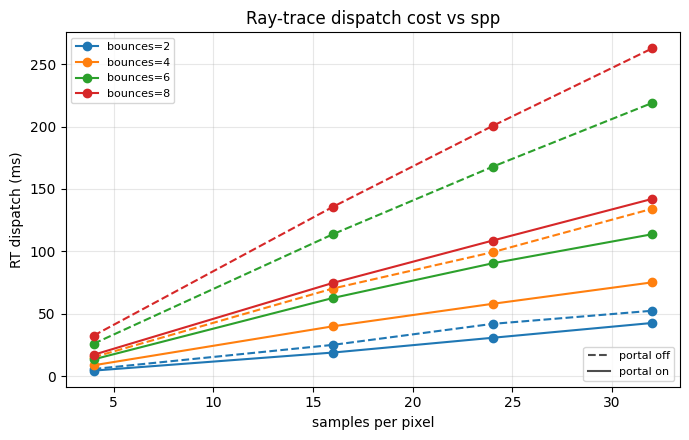

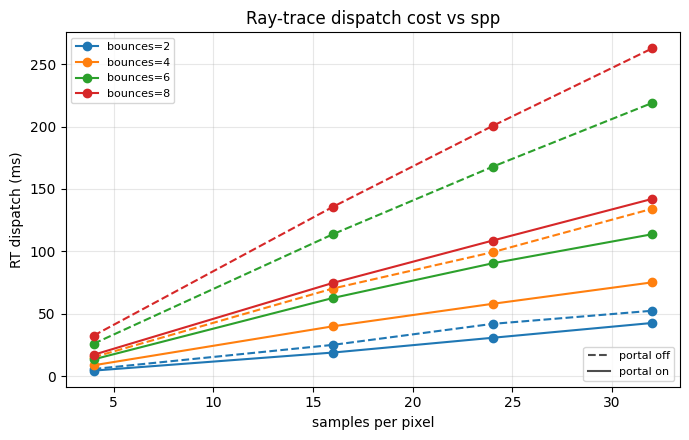

In [91]:
plots.plot_rt_vs_spp(profiles)

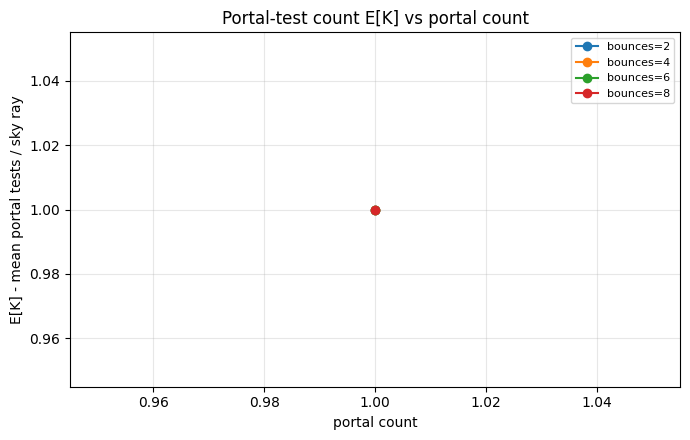

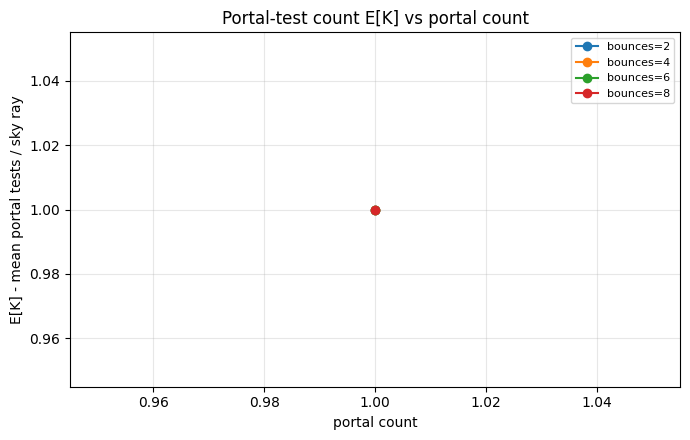

In [92]:
# add more sessions (other portal counts) to see the trend:
#   plots.plot_ek_vs_portal_count([sess, load.load_session(other_dir)])
plots.plot_ek_vs_portal_count([sess])

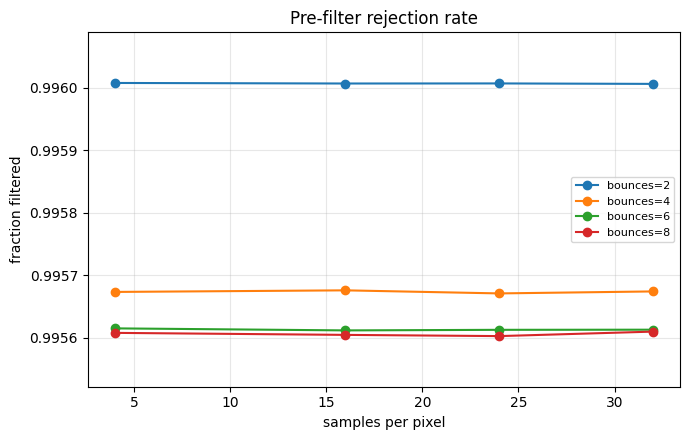

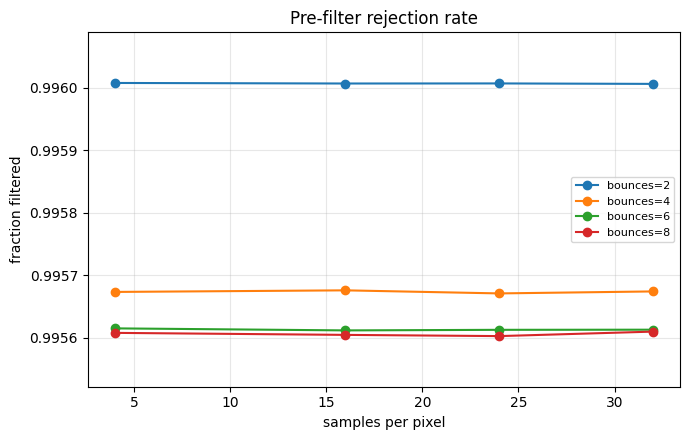

In [93]:
plots.plot_pct_filtered(profiles)

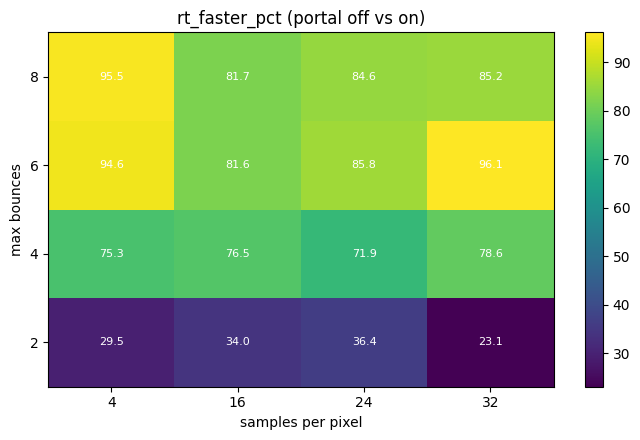

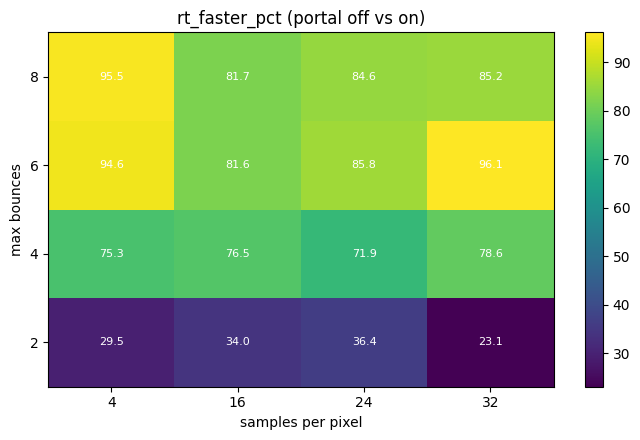

In [94]:
plots.plot_speedup_heatmap(paired)

### Save figures to `<session>/analysis/`

wrote P:\Edu\FRTEngine2\Local\Profiling\session\analysis\rt_vs_spp.png P:\Edu\FRTEngine2\Local\Profiling\session\analysis\rt_vs_spp.pdf
wrote P:\Edu\FRTEngine2\Local\Profiling\session\analysis\ek_vs_portal_count.png P:\Edu\FRTEngine2\Local\Profiling\session\analysis\ek_vs_portal_count.pdf
wrote P:\Edu\FRTEngine2\Local\Profiling\session\analysis\pct_filtered.png P:\Edu\FRTEngine2\Local\Profiling\session\analysis\pct_filtered.pdf
wrote P:\Edu\FRTEngine2\Local\Profiling\session\analysis\speedup_heatmap.png P:\Edu\FRTEngine2\Local\Profiling\session\analysis\speedup_heatmap.pdf


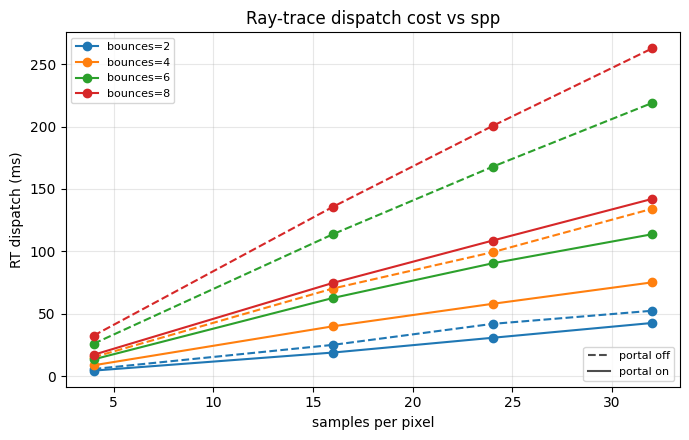

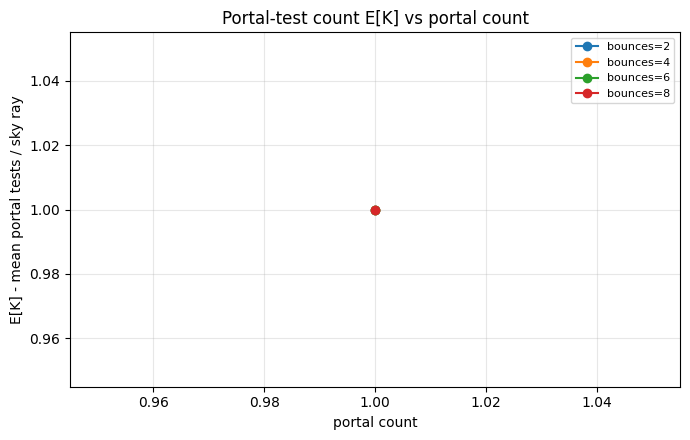

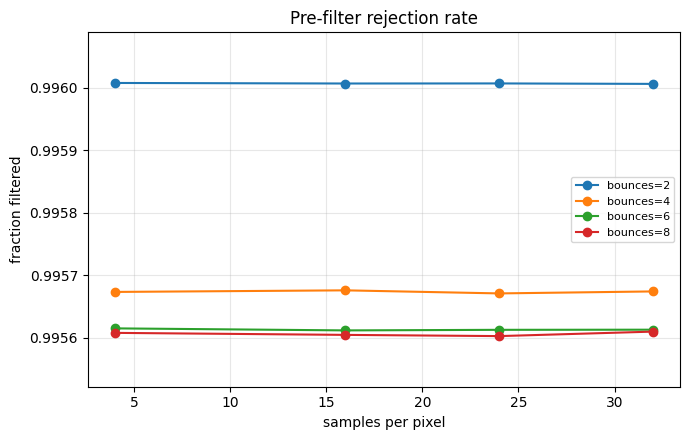

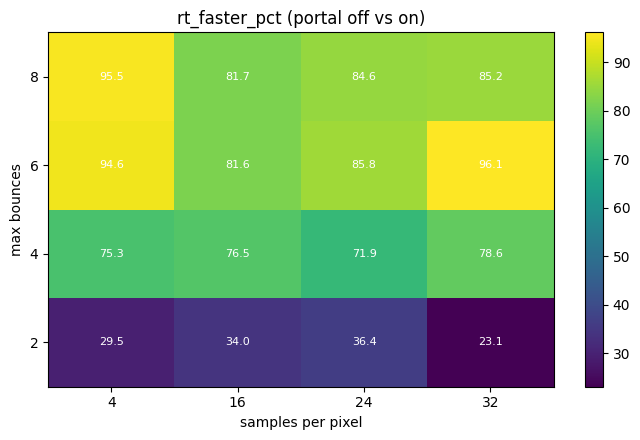

In [95]:
figs = {
    "rt_vs_spp": plots.plot_rt_vs_spp(profiles),
    "ek_vs_portal_count": plots.plot_ek_vs_portal_count([sess]),
    "pct_filtered": plots.plot_pct_filtered(profiles),
    "speedup_heatmap": plots.plot_speedup_heatmap(paired),
}
for name, fig in figs.items():
    written = plots.save_fig(fig, OUT_DIR, name)
    print("wrote", *written)

## Tables

### T1 — scene setup

Static `SceneDescriptor`: resolution, geometry, lights, portals. Fixed per
session — written to `t1_scene.tex` / `.md`.

In [96]:
scene = metrics.scene_table(sess["configs"], portals)
tables.write_table(scene, OUT_DIR, "t1_scene")
print(tables.to_markdown(scene))

| field                   | value                             |
| ----------------------- | --------------------------------- |
| render resolution       | 1242 x 673                        |
| entities                | 11                                |
| triangles               | 301469                            |
| point lights            | 0                                 |
| directional lights      | 0                                 |
| area-quad lights        | 0                                 |
| portals                 | 1                                 |
| portal coverage (total) | 0.00531                           |
| camera position         | (4.9, 2.2, -1.5)                  |
| camera rotation         | (-0.038, -1.356, 0.0)             |
| sun direction           | (-0.0, -1.0, -0.0)                |
| sun intensity           | 8.0                               |
| sky intensity           | 1.0                               |
| portal 0                | rect, area 2

### T2 — results, full sweep (appendix)

One row per (spp, bounces); `rr_depth` averaged out. Written to
`t2_appendix.tex` / `.md`.

In [97]:
t2 = metrics.results_table(paired)
tables.write_table(t2, OUT_DIR, "t2_appendix")
print(tables.to_markdown(t2))

| spp | bounces | rt_off_ms | rt_on_ms | rt_faster_pct | frame_off_ms | frame_on_ms | frame_faster_pct | pct_filtered_% |
| --- | ------- | --------- | -------- | ------------- | ------------ | ----------- | ---------------- | -------------- |
| 4   | 2       | 5.604     | 4.328    | 29.493        | 8.333        | 8.321       | 0.142            | 99.601         |
| 4   | 4       | 15.093    | 8.593    | 75.645        | 17.369       | 11.218      | 54.825           | 99.567         |
| 4   | 6       | 25.880    | 13.337   | 94.040        | 28.482       | 16.135      | 76.529           | 99.561         |
| 4   | 8       | 32.383    | 17.019   | 90.276        | 35.721       | 19.220      | 85.851           | 99.561         |
| 16  | 2       | 24.979    | 18.814   | 32.768        | 27.602       | 20.654      | 33.637           | 99.601         |
| 16  | 4       | 70.185    | 39.863   | 76.067        | 73.587       | 42.238      | 74.219           | 99.568         |
| 16  | 6       | 113.72

### T2 — results, 3 best + 3 worst (in-text)

Same columns as the appendix table, cut to its extremes by `rt_faster_pct`.
Written to `t2_intext.tex` / `.md`.

In [98]:
t2_intext = metrics.results_extremes(t2, n=3)
tables.write_table(t2_intext, OUT_DIR, "t2_intext")
print(tables.to_markdown(t2_intext))

| spp | bounces | rt_off_ms | rt_on_ms | rt_faster_pct | frame_off_ms | frame_on_ms | frame_faster_pct | pct_filtered_% |
| --- | ------- | --------- | -------- | ------------- | ------------ | ----------- | ---------------- | -------------- |
| 4   | 6       | 25.880    | 13.337   | 94.040        | 28.482       | 16.135      | 76.529           | 99.561         |
| 32  | 6       | 218.981   | 113.691  | 92.610        | 221.343      | 116.247     | 90.407           | 99.561         |
| 4   | 8       | 32.383    | 17.019   | 90.276        | 35.721       | 19.220      | 85.851           | 99.561         |
| 16  | 2       | 24.979    | 18.814   | 32.768        | 27.602       | 20.654      | 33.637           | 99.601         |
| 4   | 2       | 5.604     | 4.328    | 29.493        | 8.333        | 8.321       | 0.142            | 99.601         |
| 32  | 2       | 52.335    | 42.531   | 23.052        | 54.184       | 45.081      | 20.191           | 99.601         |


## Cost model — equation (2.8a)

`validate_eq_28a` fits the thesis portal pre-filter cost equation across the
whole sweep:

    dC = r * E[C_TLAS|P=0] - E[K] * C_quad

It is a decomposition fitted to the measured `rt_off - rt_on`, not a one-row
predictor. The fit reports R^2, RMSE and the per-ray saving `dC`. When `r` and
`E[K]` are near-constant across the sweep the two cost constants are not
separately identifiable — the printout flags this via the design condition
number.

In [99]:
result = costmodel.validate_eq_28a(paired)

[eq 2.8a] fit over 48 configs:  R^2 = 0.9202   RMSE = 11.006 ms
          E[C_TLAS|P=0] = -3.404e-03 ms/ray    C_quad = -3.391e-03 ms/test
          mean dC = 1.307e-06 +/- 6.812e-07 ms/ray  (identifiable)
          across this sweep, so C_quad and E[C_TLAS|P=0] are NOT separately identifiable.
          The combined fit and mean dC stay valid; profile a scene with varying
          r / E[K] (multi-portal, varied geometry) to pin the two constants apart.
